# 高保真合成 EEG（MNE `simulation` + fsaverage）

本笔记本使用 **MNE-Python** 的 `mne.simulation`：在 **fsaverage** 标准脑上建立源空间与三层 BEM 容积导体模型，通过 **SourceSimulator** 定义皮层电流源，再用 **simulate_raw** 投影到 **10–20 标准 16 导 EEG**，并在传感器域叠加噪声。

**生理学场景（与管线标签一致）**：
- **站立 / 平台扰动下的姿势控制**：在额–顶–运动相关皮层引入 **1–4 Hz（δ）与 4–8 Hz（θ）** 的带通噪声，模拟缓慢、大幅度的姿势纠错与皮层–脊髓协同（非纯正弦，更符合宽带神经群体活动）。
- **枕叶 α**：在枕叶皮层生成 **~10 Hz 窄带** 的带通噪声，并整体 **压低幅度**，模拟睁眼 / 注意负荷下 **α 抑制**（仍保留节律性“粗糙度”而非单频正弦）。
- **C 类外周受阻 / 肌电伪迹**：在颞叶标签附近注入 **50–100 Hz 宽带** 短时爆发（汉宁窗），模拟 **咬牙 / 颞肌紧张** 等高频肌电经容积传导在 T3/T4 附近的投影。

**环境**：需安装 MNE（若未安装，在终端执行 `pip install mne`）。首次运行会下载 **fsaverage** 解剖数据。

In [1]:
# 交互式绘图：若在 JupyterLab / VS Code 中已安装 ipympl，可改为 %matplotlib widget 以支持缩放平移
%matplotlib inline

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

import mne
from mne.datasets import fetch_fsaverage
from mne.simulation import SourceSimulator, add_noise, simulate_raw

from pathlib import Path

mne.set_log_level("INFO")

In [2]:
# ---------------------------------------------------------------------------
# 采集参数：10 s、250 Hz、16 路 EEG（标准 10–20 命名）
# ---------------------------------------------------------------------------
SFREQ = 250.0
DURATION_SEC = 10.0
N_SAMPLES = int(DURATION_SEC * SFREQ)
TSTEP = 1.0 / SFREQ

# 用户期望的电极名（部分旧文献命名在 MNE 的 standard_1020 中对应 T7/T8/P7/P8）
CH_NAMES = [
    "Fp1", "Fp2", "F3", "F4", "C3", "C4", "P3", "P4",
    "O1", "O2", "F7", "F8", "T3", "T4", "T5", "T6",
]
LEGACY_TO_MNE = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}

RNG = np.random.default_rng(42)

In [3]:
# ---------------------------------------------------------------------------
# 标准蒙太奇：为每个逻辑通道名绑定 3D 位置（容积传导 / 正向模型必需）
# ---------------------------------------------------------------------------
std_montage = mne.channels.make_standard_montage("standard_1020")
pos_dict = std_montage.get_positions()
ch_pos = {}
for name in CH_NAMES:
    lookup = LEGACY_TO_MNE.get(name, name)
    if lookup not in pos_dict["ch_pos"]:
        raise RuntimeError(f"无法在 standard_1020 中找到电极位置：{name}（尝试 {lookup}）")
    ch_pos[name] = pos_dict["ch_pos"][lookup]

dig_montage = mne.channels.make_dig_montage(
    ch_pos=ch_pos, coord_frame="head"
)
info = mne.create_info(CH_NAMES, SFREQ, ch_types="eeg")
info.set_montage(dig_montage)

print(info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6
 chs: 16 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 16
 projs: []
 sfreq: 250.0 Hz
>


In [4]:
# ---------------------------------------------------------------------------
# 物理引擎：下载 / 使用 fsaverage；皮层源空间 + 三层 BEM + EEG 正向解
# fsaverage 提供群体平均解剖，便于可重复仿真；BEM 描述颅骨–头皮导电差异（容积传导）。
# ---------------------------------------------------------------------------
fsaverage_dir = fetch_fsaverage(
    verbose=True,
)
subjects_dir = fsaverage_dir.parent
subject = "fsaverage"

src = mne.setup_source_space(
    subject,
    spacing="oct6",
    subjects_dir=subjects_dir,
    add_dist=False,
)

conductivity = (0.3, 0.006, 0.3)  # 脑 / 颅骨 / 头皮 (S/m)，经典三层球壳近似
bem_model = mne.make_bem_model(
    subject=subject,
    ico=4,
    conductivity=conductivity,
    subjects_dir=subjects_dir,
)
bem_sol = mne.make_bem_solution(bem_model)

# trans='fsaverage'：标准电极与平均 MRI 对齐（MNE 内置快捷方式）
fwd = mne.make_forward_solution(
    info,
    trans="fsaverage",
    src=src,
    bem=bem_sol,
    eeg=True,
    mindist=5.0,
    n_jobs=1,
)
fwd = mne.convert_forward_solution(fwd, surf_ori=True, force_fixed=True, use_cps=True)
print(fwd)

0 files missing from root.txt in /home/zhang/mne_data/MNE-fsaverage-data
0 files missing from bem.txt in /home/zhang/mne_data/MNE-fsaverage-data/fsaverage
Setting up the source space with the following parameters:

SUBJECTS_DIR = /home/zhang/mne_data/MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 6

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading /home/zhang/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.white...
Mapping lh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /home/zhang/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 4098/163842 selected to source space (oct = 6)

Loading /home/zhang/mne_data/MNE-fsaverage-data/fsaverage/surf/rh.white...
Mapping rh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /home/zhang/mne_data/MNE-fsave

In [5]:
# ---------------------------------------------------------------------------
# 工具：带通滤波噪声（在时域用白噪声 + FIR 带通，避免“纯音”式正弦）
# ---------------------------------------------------------------------------
def bandpass_noise(
    n_samples: int,
    sfreq: float,
    fmin: float,
    fmax: float,
    rng: np.random.Generator,
    pad_sec: float = 2.0,
) -> np.ndarray:
    """两侧padding后滤波再裁切，减轻边缘振铃。"""
    pad = int(pad_sec * sfreq)
    x = rng.standard_normal(n_samples + 2 * pad)
    x = mne.filter.filter_data(
        x[np.newaxis, :],
        sfreq,
        l_freq=fmin,
        h_freq=min(fmax, sfreq / 2.0 - 1.0),
        method="fir",
        fir_window="hamming",
        verbose=False,
    )[0]
    return x[pad : pad + n_samples]


def peak_scale(x: np.ndarray, peak_amp: float) -> np.ndarray:
    """按峰值缩放到目标幅度（A·m，与 MNE 偶极子单位一致）。"""
    m = np.max(np.abs(x)) + 1e-30
    return (x / m) * peak_amp


def pick_label(subject: str, subjects_dir: str, regexp: str) -> mne.Label:
    """从 FreeSurfer aparc 读取单个标签；regexp 需唯一匹配一个标签文件。"""
    labs = mne.read_labels_from_annot(
        subject,
        parc="aparc",
        subjects_dir=subjects_dir,
        regexp=regexp,
        verbose=False,
    )
    if len(labs) != 1:
        raise RuntimeError(f"regexp {regexp!r} 匹配到 {len(labs)} 个标签，需唯一。")
    return labs[0]


def restrict_label(
    subject: str,
    subjects_dir: str,
    lab: mne.Label,
    extent_mm: float = 35.0,
) -> mne.Label:
    """限制标签空间范围，使源更局部化（近似“斑块”激活，而非整叶均匀电流）。"""
    return mne.label.select_sources(
        subject,
        lab,
        location="center",
        extent=extent_mm,
        subjects_dir=subjects_dir,
    )

In [6]:
# ---------------------------------------------------------------------------
# 解剖标签选择（与电极功能大致对应；真实容积传导会使场型扩散到邻近电极）
# - 枕叶：cuneus（距状裂附近，O1/O2 对侧投影主要成分）
# - 姿势控制：precentral + postcentral（运动/感觉整合，F3/F4/C3/C4 附近场强常显著）
# - 颞叶肌电：superior temporal（T3/T4 附近高频伪迹常见入口）
# ---------------------------------------------------------------------------
lab_cuneus_lh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^cuneus-lh$"))
lab_cuneus_rh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^cuneus-rh$"))

lab_prec_lh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^precentral-lh$"))
lab_prec_rh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^precentral-rh$"))
lab_post_lh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^postcentral-lh$"))
lab_post_rh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^postcentral-rh$"))

lab_st_lh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^superiortemporal-lh$"))
lab_st_rh = restrict_label(subject, str(subjects_dir), pick_label(subject, str(subjects_dir), "^superiortemporal-rh$"))

In [7]:
# ---------------------------------------------------------------------------
# 源时间过程：三类信号在 0～10 s 上连续叠加（线性叠加 ≈ 多源容积传导近似）
# ---------------------------------------------------------------------------
n = N_SAMPLES

# 1) 枕叶 α：9–11 Hz 带通噪声，幅度压低 → “被抑制的 α”
alpha_lh = peak_scale(bandpass_noise(n, SFREQ, 9.0, 11.0, RNG), peak_amp=6e-9)
alpha_lh *= 0.35
alpha_rh = peak_scale(bandpass_noise(n, SFREQ, 9.0, 11.0, RNG), peak_amp=6e-9)
alpha_rh *= 0.35

# 2) 姿势控制：δ + θ 高幅带通噪声
delta = peak_scale(bandpass_noise(n, SFREQ, 1.0, 4.0, RNG), peak_amp=35e-9)
theta = peak_scale(bandpass_noise(n, SFREQ, 4.0, 8.0, RNG), peak_amp=28e-9)
posture = 1.15 * (delta + theta)

# 3) 颞叶高频“肌电”爆发：整段先带通 50–100 Hz，再用汉宁窗在 3 s、7 s 各贴 0.4 s
pad = int(2.0 * SFREQ)
wide = RNG.standard_normal(n + 2 * pad)
wide = mne.filter.filter_data(
    wide[np.newaxis, :],
    SFREQ,
    l_freq=50.0,
    h_freq=min(100.0, SFREQ / 2.0 - 1.0),
    method="fir",
    fir_window="hamming",
    verbose=False,
)[0]
wide = wide[pad : pad + n]
emg = np.zeros(n, dtype=float)
burst_dur = 0.4
burst_n = int(burst_dur * SFREQ)
win = np.hanning(burst_n)
burst_peak = 95e-9
for t0 in (3.0, 7.0):
    s = int(t0 * SFREQ)
    e = min(s + burst_n, n)
    nb = e - s
    seg = wide[s:e]
    seg = seg / (np.max(np.abs(seg)) + 1e-30) * burst_peak
    emg[s:e] += seg * win[:nb]

events = np.array([[0, 0, 1]], dtype=int)

src_sim = SourceSimulator(src, tstep=TSTEP, duration=DURATION_SEC)
# 枕叶（双侧 α）
src_sim.add_data(lab_cuneus_lh, alpha_lh, events)
src_sim.add_data(lab_cuneus_rh, alpha_rh, events)
# 姿势控制（双侧运动–感觉皮层）；多斑块共享同一时间过程时需缩放，避免数值上相当于多倍偶极子简单相加
posture_patch = posture * 0.28
for lab in (lab_prec_lh, lab_prec_rh, lab_post_lh, lab_post_rh):
    src_sim.add_data(lab, posture_patch, events)
# 颞叶高频爆发（双侧对称紧张）
src_sim.add_data(lab_st_lh, emg, events)
src_sim.add_data(lab_st_rh, emg, events)

print("SourceSimulator n_times:", src_sim.n_times)

SourceSimulator n_times: 2500


In [8]:
# ---------------------------------------------------------------------------
# 传感器空间：正向投影 + 适度传感器噪声（模拟放大器 / 环境噪声）
# ---------------------------------------------------------------------------
raw_sim = simulate_raw(info, src_sim, forward=fwd, verbose=True)

# 平均参考更符合常规 EEG 解释；再叠加 ad hoc 协方差噪声
raw_sim.set_eeg_reference("average", projection=True)
noise_cov = mne.make_ad_hoc_cov(raw_sim.info, std=4e-6)
add_noise(raw_sim, cov=noise_cov, iir_filter=[0.2, -0.2, 0.04], random_state=0)

raw_sim.pick("eeg")
print(raw_sim)
print("持续时间 (s):", raw_sim.times[-1])

Setting up raw simulation: 1 position, "cos2" interpolation
Event information not stored
    Interval 0.000–4.000 s
Setting up forward solutions
    Interval 0.000–4.000 s
    Interval 0.000–2.000 s
    3 STC iterations provided
[done]
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Adding noise to 16/16 channels (16 channels in cov)
<RawArray | 16 x 2500 (10.0 s), ~337 KiB, data loaded>
持续时间 (s): 9.996


In [9]:
# MNE 交互式滚动查看（scalings 控制垂直分辨率；单位 V）
raw_sim.plot(
    duration=DURATION_SEC,
    n_channels=len(raw_sim.ch_names),
    scalings=dict(eeg=5e-5),
    title="合成 16 导 EEG（站立姿势 + 枕 α 抑制 + 颞肌高频爆发）",
)

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x62f0f26d5090) at 0x7402d7af2e40>

Channels marked as bad:
none


/home/zhang/miniforge3/envs/eeg_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhang/miniforge3/envs/eeg_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhang/miniforge3/envs/eeg_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhang/miniforge3/envs/eeg_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhang/miniforge3/envs/eeg_env/lib/python3.13/site-packages/IPython/cor

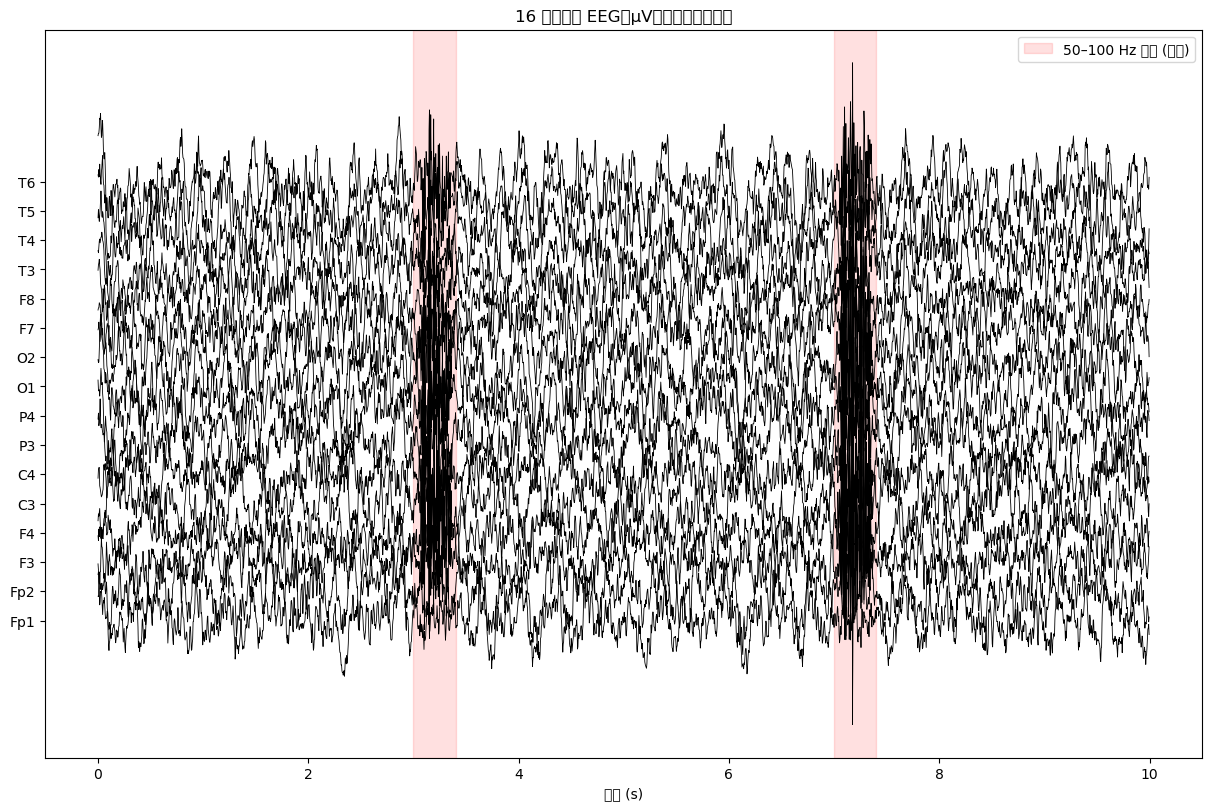

In [10]:
# Matplotlib：整段 10 s 叠图（便于论文式总览；伪迹在 T3/T4 等通道更明显）
data = raw_sim.get_data() * 1e6  # µV
times = raw_sim.times
offset = np.arange(data.shape[0])[:, None] * 80.0  # 垂直偏移 µV
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
ax.plot(times, (data + offset).T, color="k", linewidth=0.6)
ax.set_yticks(offset[:, 0])
ax.set_yticklabels(raw_sim.ch_names)
ax.set_xlabel("时间 (s)")
ax.set_title("16 通道合成 EEG（µV，人工偏移显示）")
ax.axvspan(3.0, 3.4, color="red", alpha=0.12, label="50–100 Hz 爆发 (示例)")
ax.axvspan(7.0, 7.4, color="red", alpha=0.12)
ax.legend(loc="upper right")
plt.show()

## 人头 / 容积模型可视化（与上文对象一致）

以下三格分别对应 **对齐图**、**BEM + MRI 切片**、**源估计 STC**，直接使用前面已算好的 `info`、`subject`、`subjects_dir`、`bem_sol`、`src`、`src_sim`（与 `make_forward_solution` / `SourceSimulator` 同源）。

- **方案 1 / 3**：**PyVista 三维**（可鼠标旋转）；依赖 `pyvista`、`vtk`、`trame` 等在 notebook 内嵌。
- **方案 2**：**Matplotlib 二维**——在 fsaverage 的 MRI 切片上叠加 BEM 轮廓与源点，便于看「三层壳 + 源网格」解剖关系。

**内核**：请在 Jupyter / VS Code 中选择解释器 / 内核 **`eeg_env`**。若 3D 无法内嵌，先安装：

`mamba install -n eeg_env -c conda-forge pyvista vtk trame ipywidgets ipyevents`

（可选）`mamba install -n eeg_env -c conda-forge pyvistaqt`，以便弹出独立 3D 窗口交互。

**用法**：由上至下依次运行三格代码即可；若已跑完前文仿真，无需改变量名。

In [14]:
# ---------------------------------------------------------------------------
# 方案 1：plot_alignment — 电极（与 info 中 dig 一致）+ BEM + 源空间顶点
# 与计算 fwd 时使用的 trans='fsaverage'、bem_sol、src 对齐，便于理解容积传导几何。
# ---------------------------------------------------------------------------
import pyvista as pv

# 在 Notebook 中尽量使用可交互内嵌后端（依次尝试）
for _backend in ("trame", "html", "static"):
    try:
        pv.set_jupyter_backend(_backend)
        break
    except Exception:
        continue

fig_alignment = mne.viz.plot_alignment(
    info=info,
    trans="fsaverage",
    subject=subject,
    subjects_dir=subjects_dir,
    bem=bem_sol,
    eeg=True,
    src=src,
    mri_fiducials=True,
    dig=True,
    verbose=False,
)

Using surface: /home/zhang/mne_data/MNE-fsaverage-data/fsaverage/bem/inner_skull.surf
Using surface: /home/zhang/mne_data/MNE-fsaverage-data/fsaverage/bem/outer_skull.surf
Using surface: /home/zhang/mne_data/MNE-fsaverage-data/fsaverage/bem/outer_skin.surf


/home/zhang/miniforge3/envs/eeg_env/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


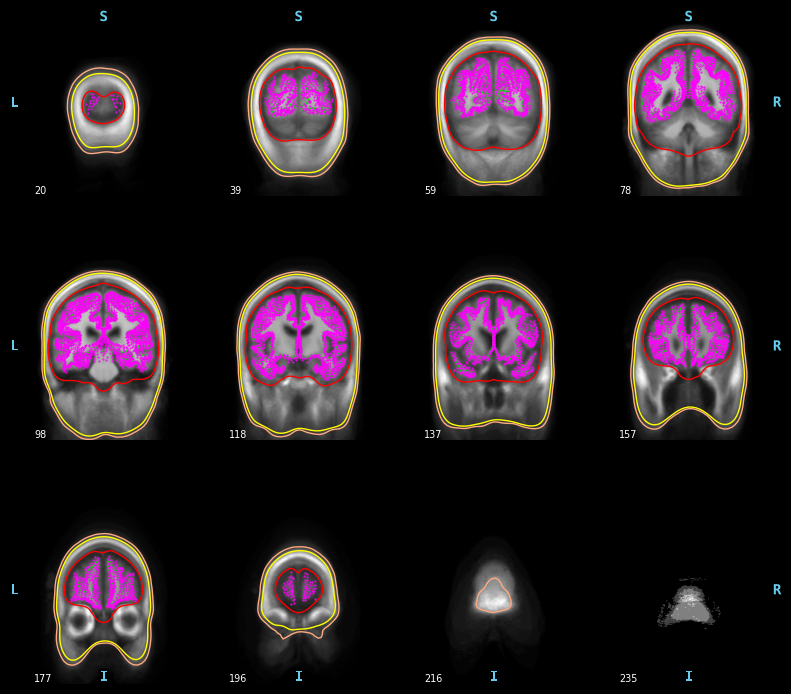

In [12]:
# ---------------------------------------------------------------------------
# 方案 2：plot_bem — 三层头模型表面（脑 / 颅骨内外 / 头皮）+ 源空间
# 直观对应 make_bem_model / make_bem_solution 所描述的容积导体分层。
# ---------------------------------------------------------------------------
fig_bem = mne.viz.plot_bem(
    subject=subject,
    subjects_dir=subjects_dir,
    brain_surfaces="white",
    src=src,
    orientation="coronal",
)

In [13]:
# ---------------------------------------------------------------------------
# 方案 3：SourceSimulator → STC → 皮层表面动画
# get_stc() 与随后 simulate_raw 使用的是同一套源时间过程；initial_time=7 s 接近颞叶高频爆发段。
# time_viewer=True 打开时间滑条，可在 Notebook / 独立窗口中拖动查看。
# ---------------------------------------------------------------------------
stc_sim = src_sim.get_stc()

brain = stc_sim.plot(
    subject=subject,
    subjects_dir=subjects_dir,
    hemi="split",
    views="lat",
    initial_time=7.0,
    time_viewer=True,
    clim=dict(kind="percent", lims=[92.0, 96.0, 99.5]),
    smoothing_steps=10,
    size=(900, 600),
)

Using control points [6.49618990e-09 1.05263613e-08 2.33912095e-08]
